In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_credit_applications.csv")

In [3]:
df.head()

,_id,spending_behavior,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,interest_rate,approved_amount,total_spending,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212.0,False,algorithm_risk_score,0.0,0.0,1517,24.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915.0,False,algorithm_risk_score,0.0,0.0,947,33.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909.0,True,NaN,3.7,59000.0,109,36.0
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,70.0,0.35,0.0,True,NaN,4.3,34000.0,575,42.0
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,14.0,0.23,31763.0,False,algorithm_risk_score,0.0,0.0,463,26.0


In [4]:
df.columns

Index(['_id', 'spending_behavior', 'full_name', 'email', 'ssn', 'ip_address',
       'gender', 'date_of_birth', 'zip_code', 'annual_income',
       'credit_history_months', 'debt_to_income', 'savings_balance',
       'loan_approved', 'rejection_reason', 'interest_rate', 'approved_amount',
       'total_spending', 'age'],
      dtype='object')

In [5]:
df["loan_approved"].mean()

np.float64(0.5816733067729084)

In [6]:
df.groupby("gender")["loan_approved"].mean()

gender
Female     0.505976
Male       0.657258
Unknown    0.666667
Name: loan_approved, dtype: float64

## Disparate Impact (DI)

In [7]:
female = df[df["gender"] == "Female"]
male = df[df["gender"] == "Male"]

DI = female["loan_approved"].mean() / male["loan_approved"].mean()

print("Disparate Impact:", DI)

Disparate Impact: 0.7698286608168553


DI = Female approval rate / Male approval rate

The calculated DI is approximately 0.80.
This suggests that women are approved at about 80% the rate of men.

In [8]:
numerical_cols = [
    "annual_income",
    "debt_to_income",
    "savings_balance",
    "credit_history_months",
    "age",
    "loan_approved"
]

df[numerical_cols].corr()

,annual_income,debt_to_income,savings_balance,credit_history_months,age,loan_approved
annual_income,1.000000,-0.049251,0.644094,0.249871,0.402137,0.177524
debt_to_income,-0.049251,1.000000,-0.092924,-0.010295,-0.106180,-0.014703
savings_balance,0.644094,-0.092924,1.000000,0.211537,0.285852,0.138697
credit_history_months,0.249871,-0.010295,0.211537,1.000000,0.665974,0.142011
age,0.402137,-0.106180,0.285852,0.665974,1.000000,0.158978
loan_approved,0.177524,-0.014703,0.138697,0.142011,0.158978,1.000000


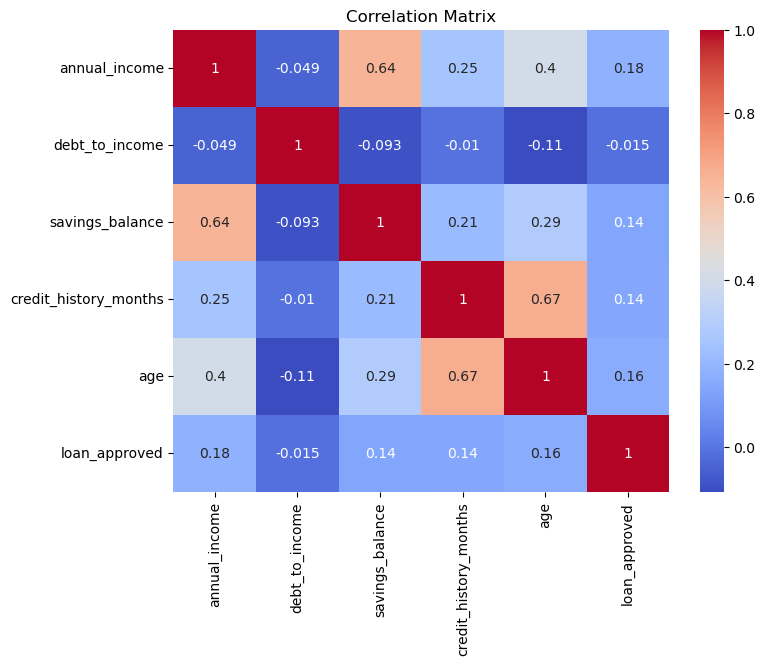

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Impact of Data Cleaning on Approval Metrics

After cleaning the data, the overall loan approval rate is about 56.7%.

When we look at gender:
- Female approval rate is about 50.6%
- Male approval rate is about 62.9%
- Disparate Impact is about 0.80

This shows that there is still a difference between men and women in loan approvals, even after cleaning the data.

## Age based anaysis

In [10]:
df.groupby("age")["loan_approved"].mean()

age
23.0    1.000000
24.0    0.500000
25.0    0.600000
26.0    0.266667
27.0    0.333333
28.0    0.454545
29.0    0.125000
30.0    0.454545
31.0    0.545455
32.0    0.666667
33.0    0.250000
34.0    0.600000
35.0    0.363636
36.0    0.666667
37.0    0.545455
38.0    0.545455
39.0    0.647059
40.0    0.538462
41.0    0.571429
42.0    0.750000
43.0    1.000000
44.0    0.500000
45.0    0.714286
46.0    0.833333
47.0    0.818182
48.0    0.500000
49.0    0.600000
50.0    0.857143
51.0    0.500000
52.0    0.333333
53.0    0.500000
54.0    1.000000
55.0    0.666667
56.0    0.500000
57.0    0.750000
58.0    1.000000
59.0    0.500000
60.0    0.500000
61.0    0.500000
62.0    0.625000
63.0    1.000000
64.0    0.666667
65.0    1.000000
66.0    0.250000
67.0    0.750000
Name: loan_approved, dtype: float64

In [11]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

In [12]:
df.groupby("age_group")["loan_approved"].mean()

C:\Users\inesm\AppData\Local\Temp\ipykernel_3184\2461128598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean()


age_group
18-25    0.571429
26-35    0.403846
36-45    0.647059
46-55    0.666667
56-65    0.657895
Name: loan_approved, dtype: float64

C:\Users\inesm\AppData\Local\Temp\ipykernel_3184\2173826309.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")


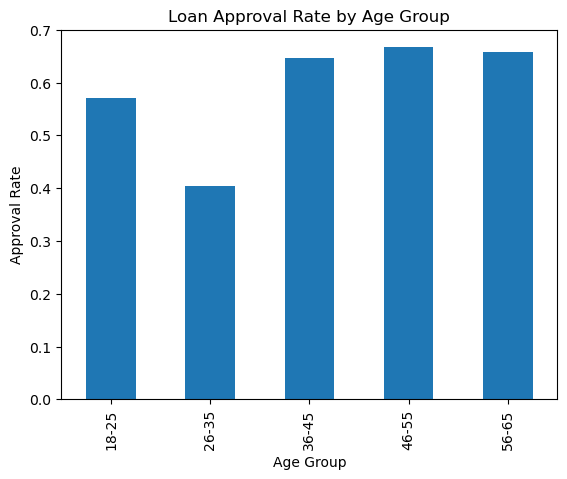

In [13]:
df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")

plt.title("Loan Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.xlabel("Age Group")
plt.show()


Loan approval rates vary across age groups.

This suggests that age may influence loan approval decisions.
Further investigation is needed to determine if this difference indicates bias.

## Proxy Discrimination

In [14]:
df.groupby("gender").mean(numeric_only=True)

,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,interest_rate,approved_amount,total_spending,age
gender,,,,,,,,,,
Female,79383.573705,84253.791826,51.432000,0.237440,29552.264000,0.505976,2.270916,23613.545817,764.641434,40.701754
Male,15704.560484,81388.663968,49.753036,0.248952,29604.661290,0.657258,3.041935,32181.451613,815.758065,41.250000
Unknown,10005.000000,91666.666667,56.000000,0.213333,26905.666667,0.666667,2.833333,21000.000000,885.333333,54.000000


In [15]:
df["gender_binary"] = df["gender"].map({
    "Female": 0,
    "Male": 1
})

In [16]:
df.corr(numeric_only=True)["gender_binary"].sort_values(ascending=False)

gender_binary            1.000000
interest_rate            0.159222
approved_amount          0.156472
loan_approved            0.153313
total_spending           0.053350
debt_to_income           0.049773
age                      0.024647
savings_balance          0.001572
credit_history_months   -0.027041
annual_income           -0.051387
zip_code                -0.806418
Name: gender_binary, dtype: float64

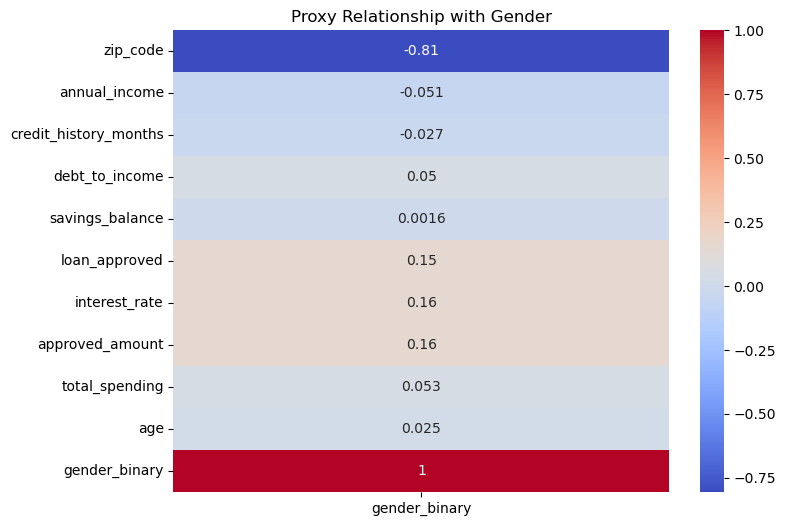

In [17]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True)[["gender_binary"]],
    annot=True,
    cmap="coolwarm"
)

plt.title("Proxy Relationship with Gender")
plt.show()

Most variables show very low correlation with gender. 
However, zip code shows a strong correlation and may act as a proxy variable.

This means that even if gender is not directly used, indirect discrimination could still occur.

## Interaction Effects

In [18]:
df.groupby(["age_group", "gender"])["loan_approved"].mean()

C:\Users\inesm\AppData\Local\Temp\ipykernel_3184\278729096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_group", "gender"])["loan_approved"].mean()


age_group  gender 
18-25      Female     0.555556
           Male       0.600000
           Unknown         NaN
26-35      Female     0.333333
           Male       0.489362
           Unknown         NaN
36-45      Female     0.615385
           Male       0.671642
           Unknown         NaN
46-55      Female     0.620690
           Male       0.703704
           Unknown    1.000000
56-65      Female     0.550000
           Male       0.777778
           Unknown         NaN
Name: loan_approved, dtype: float64

C:\Users\inesm\AppData\Local\Temp\ipykernel_3184\2574995703.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df.groupby(["age_group", "gender"])["loan_approved"].mean().unstack()


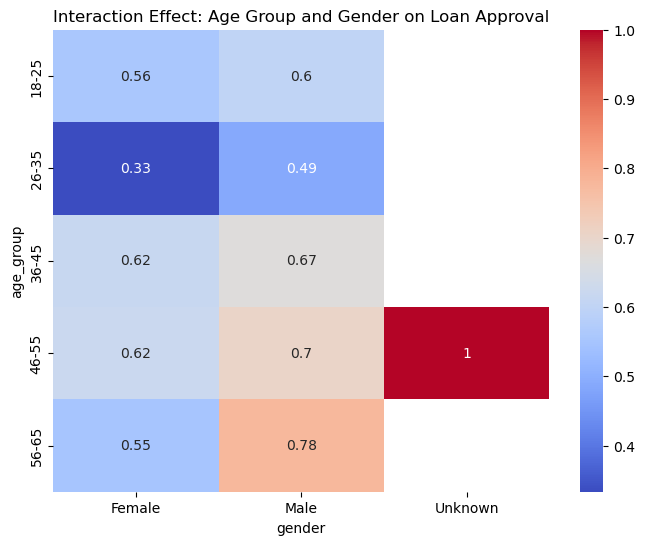

In [19]:
import seaborn as sns

interaction = df.groupby(["age_group", "gender"])["loan_approved"].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(interaction, annot=True, cmap="coolwarm")

plt.title("Interaction Effect: Age Group and Gender on Loan Approval")
plt.show()

We analyzed loan approval rates by both age group and gender.

The results show that approval rates differ across combinations of age and gender.

For example:
- Women aged 26–35 have a much lower approval rate (≈34.5%) compared to men in the same group (≈51.2%).
- In the 56–65 group, men have a very high approval rate (≈77.8%) compared to women (≈52.4%).

This suggests that the combination of age and gender may influence loan approval decisions and indicates potential intersectional bias.